In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
nav_df = pd.read_csv("../data/processed_data/nav_history_clean.csv")

txn = pd.read_csv("../data/processed_data/investor_transactions_clean.csv")

fund_meta = pd.read_csv("../data/processed_data/fund_master_clean.csv")

portfolio = pd.read_csv("../data/processed_data/portfolio_holdings_clean.csv")

In [3]:
nav_df.head()

txn.head()

fund_meta.head()

portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [5]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

txn["transaction_date"] = pd.to_datetime(txn["transaction_date"])

In [6]:
nav_df = nav_df.sort_values(["amfi_code", "date"])

nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
          .pct_change()
)

In [7]:
risk_metrics = []

for fund, grp in nav_df.groupby("amfi_code"):

    returns = grp["daily_return"].dropna()

    if len(returns) == 0:
        continue

    var95 = np.percentile(returns, 5)
    cvar95 = returns[returns <= var95].mean()

    risk_metrics.append({
        "amfi_code": fund,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

var_cvar_df = pd.DataFrame(risk_metrics)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [8]:
var_cvar_df.to_csv(
    "var_cvar_report.csv",
    index=False
)

In [9]:
# cohort
txn["first_year"] = (
    txn.groupby("investor_id")["transaction_date"]
       .transform("min")
       .dt.year
)

In [10]:
cohort = txn.groupby("first_year").agg(
    avg_sip_amount=("amount_inr", "mean"),
    total_invested=("amount_inr", "sum")
).reset_index()

cohort

,first_year,avg_sip_amount,total_invested
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


In [11]:
top_fund = (
    txn.groupby(["first_year", "amfi_code"])
       .size()
       .reset_index(name="count")
)

top_fund = top_fund.loc[
    top_fund.groupby("first_year")["count"].idxmax()
]

cohort = cohort.merge(
    top_fund[["first_year", "amfi_code"]],
    on="first_year"
)

cohort.head()

,first_year,avg_sip_amount,total_invested,amfi_code
0,2024,107422.541832,3491125187,148568
1,2025,109158.577061,30455243,119599


In [14]:
cohort.to_csv("cohort_analysis.csv", index=False)

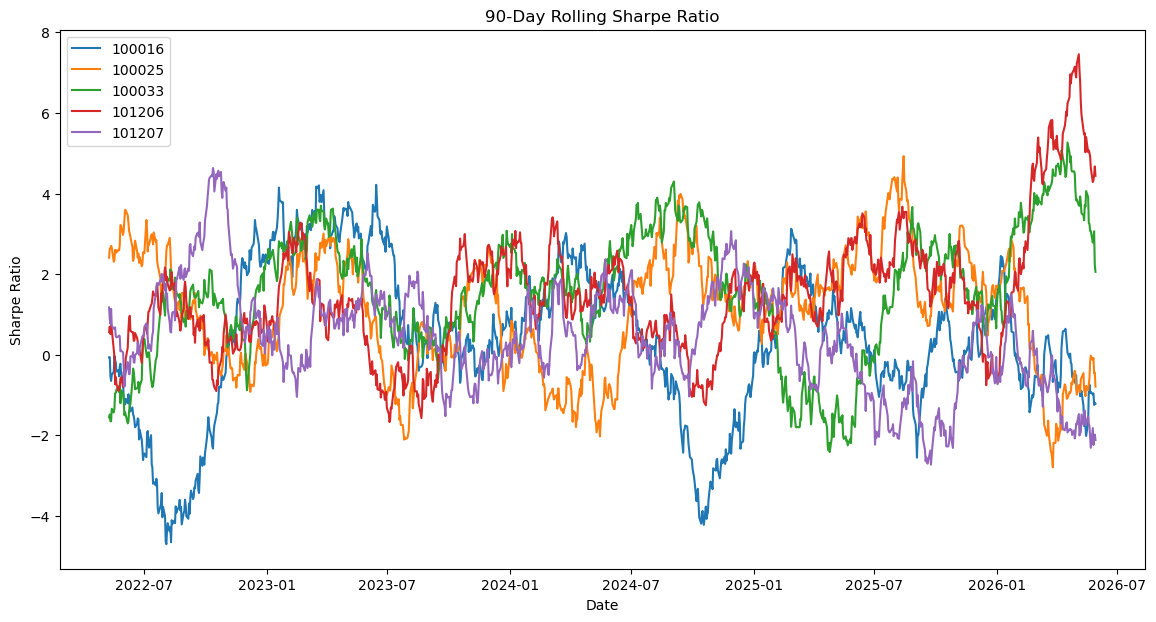

In [13]:
#rolling 
import numpy as np

rolling_sharpe = {}

# Select first 5 AMFI codes
top5_funds = nav_df["amfi_code"].unique()[:5]

for fund in top5_funds:

    temp = nav_df[nav_df["amfi_code"] == fund].copy()

    returns = temp["daily_return"]

    sharpe = (
        returns.rolling(90).mean()
        /
        returns.rolling(90).std()
    ) * np.sqrt(252)

    temp["rolling_sharpe"] = sharpe

    rolling_sharpe[fund] = temp

    import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

for fund in top5_funds:

    temp = rolling_sharpe[fund]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(fund)
    )

plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()

plt.savefig("rolling_sharpe_chart.png")
plt.show()

In [16]:
#sip
sip_txn = txn[txn["transaction_type"] == "SIP"].copy()

sip_txn = sip_txn.sort_values(
    ["investor_id", "transaction_date"]
)

sip_txn["gap_days"] = (
    sip_txn.groupby("investor_id")["transaction_date"]
           .diff()
           .dt.days
)

sip_txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,first_year,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0


In [17]:
sip_gap = (
    sip_txn.groupby("investor_id")
           .agg(
               n_sips=("transaction_date", "count"),
               avg_gap=("gap_days", "mean")
           )
           .reset_index()
)

sip_gap = sip_gap[sip_gap["n_sips"] >= 6]

sip_gap["status"] = np.where(
    sip_gap["avg_gap"] > 35,
    "At-Risk",
    "Healthy"
)

sip_gap.head()

,investor_id,n_sips,avg_gap,status
3,INV000004,6,85.400000,At-Risk
7,INV000008,6,70.400000,At-Risk
9,INV000010,6,64.800000,At-Risk
10,INV000011,7,40.166667,At-Risk
11,INV000012,8,57.000000,At-Risk


In [18]:
sip_gap.to_csv(
    "sip_continuity_report.csv",
    index=False
)

In [19]:
#HHI
portfolio["weight_pct"] = pd.to_numeric(
    portfolio["weight_pct"],
    errors="coerce"
)

portfolio = portfolio.dropna(subset=["weight_pct"])

In [20]:
portfolio["weight"] = portfolio["weight_pct"] / 100

In [21]:
import numpy as np

sector_hhi = (
    portfolio.groupby("amfi_code")
             .apply(lambda x: np.sum(x["weight"] ** 2))
             .reset_index(name="HHI")
)

sector_hhi.head()

C:\Users\Aryan Sharma\AppData\Local\Temp\ipykernel_16532\1074942752.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.sum(x["weight"] ** 2))


,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [22]:
sector_hhi["Concentration"] = np.where(
    sector_hhi["HHI"] > 0.25,
    "Highly Concentrated",
    "Diversified"
)

sector_hhi.head()

,amfi_code,HHI,Concentration
0,100016,0.139534,Diversified
1,100033,0.147592,Diversified
2,101206,0.129332,Diversified
3,101207,0.200700,Diversified
4,102885,0.174709,Diversified


In [23]:
sector_hhi = sector_hhi.sort_values(
    "HHI",
    ascending=False
)

sector_hhi.head(10)

,amfi_code,HHI,Concentration
11,119092,0.206448,Diversified
3,101207,0.200700,Diversified
18,119599,0.174751,Diversified
4,102885,0.174709,Diversified
7,118632,0.168298,Diversified
29,148568,0.167930,Diversified
21,120505,0.157570,Diversified
22,120506,0.153794,Diversified
27,125498,0.152414,Diversified
23,120841,0.149680,Diversified


In [24]:
sector_hhi.to_csv(
    "sector_hhi.csv",
    index=False
)